# 📊 Notebook 01 — Exploratory Data Analysis
**Project:** Customer Churn Prediction | MLOps Pipeline

**Stack:** Pandas · Matplotlib · Seaborn

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('✅ Libraries loaded')

✅ Libraries loaded


## 1️⃣ Generate / Load Dataset
> Replace the synthetic block with `pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')` after downloading from Kaggle.

In [2]:
np.random.seed(42)
n = 7043
df = pd.DataFrame({
    'customerID':        [f'ID-{i:05d}' for i in range(n)],
    'gender':            np.random.choice(['Male','Female'], n),
    'SeniorCitizen':     np.random.choice([0, 1], n, p=[0.84, 0.16]),
    'Partner':           np.random.choice(['Yes','No'], n),
    'Dependents':        np.random.choice(['Yes','No'], n, p=[0.3, 0.7]),
    'tenure':            np.random.randint(0, 72, n),
    'PhoneService':      np.random.choice(['Yes','No'], n, p=[0.9, 0.1]),
    'MultipleLines':     np.random.choice(['Yes','No','No phone service'], n),
    'InternetService':   np.random.choice(['DSL','Fiber optic','No'], n),
    'OnlineSecurity':    np.random.choice(['Yes','No','No internet service'], n),
    'TechSupport':       np.random.choice(['Yes','No','No internet service'], n),
    'Contract':          np.random.choice(['Month-to-month','One year','Two year'], n, p=[0.55, 0.24, 0.21]),
    'PaperlessBilling':  np.random.choice(['Yes','No'], n, p=[0.59, 0.41]),
    'PaymentMethod':     np.random.choice(['Electronic check','Mailed check','Bank transfer (automatic)','Credit card (automatic)'], n),
    'MonthlyCharges':    np.round(np.random.uniform(18, 120, n), 2),
    'TotalCharges':      np.round(np.random.uniform(18, 8700, n), 2),
    'Churn':             np.random.choice(['Yes','No'], n, p=[0.265, 0.735])
})
os.makedirs('../data/raw', exist_ok=True)
df.to_csv('../data/raw/churn_raw.csv', index=False)
print(f'✅ Dataset: {df.shape[0]} rows × {df.shape[1]} cols')
df.head()

✅ Dataset: 7043 rows × 17 cols


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,ID-00000,Male,0,Yes,No,42,Yes,No,Fiber optic,No internet service,Yes,Month-to-month,Yes,Electronic check,76.12,1399.70,Yes
1,ID-00001,Female,1,Yes,Yes,68,Yes,No phone service,No,Yes,No internet service,Month-to-month,Yes,Credit card (automatic),38.32,7210.27,Yes
2,ID-00002,Male,0,No,Yes,62,Yes,Yes,No,No,No internet service,Month-to-month,No,Mailed check,21.06,2921.38,No
3,ID-00003,Male,0,Yes,No,69,Yes,Yes,No,Yes,No internet service,Two year,Yes,Bank transfer (automatic),105.41,7274.12,No
4,ID-00004,Male,0,Yes,No,64,Yes,No,Fiber optic,No internet service,Yes,Month-to-month,No,Electronic check,68.76,2196.32,No


## 2️⃣ Basic Info

In [3]:
print(df.dtypes)
print('\nMissing:\n', df.isnull().sum())
df.describe()

customerID           object
gender               object
SeniorCitizen         int32
Partner              object
Dependents           object
tenure                int32
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
TechSupport          object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
TechSupport         0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.153486,35.358512,69.128164,4384.211001
std,0.360481,20.631240,29.195145,2500.975375
min,0.000000,0.000000,18.010000,20.350000
25%,0.000000,18.000000,43.755000,2213.575000
50%,0.000000,35.000000,69.110000,4436.160000
75%,0.000000,53.000000,94.435000,6562.265000
max,1.000000,71.000000,119.990000,8698.850000


## 3️⃣ Churn Distribution

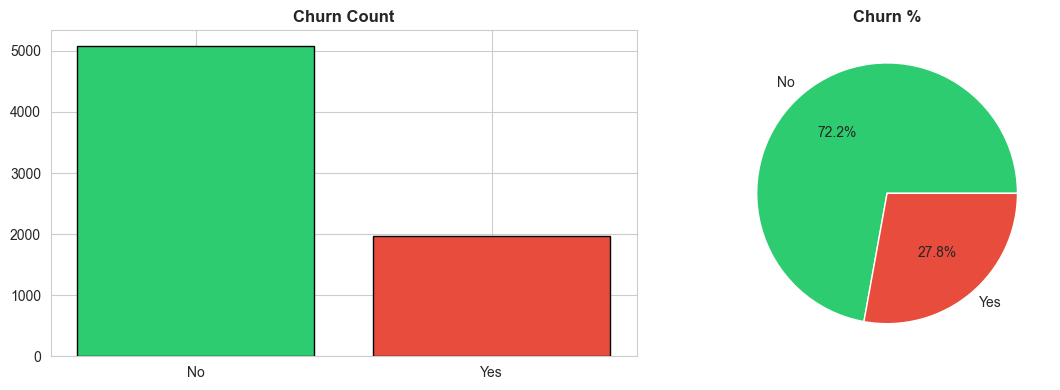

Churn rate: 27.84%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['Churn'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Count', fontweight='bold')
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[1].set_title('Churn %', fontweight='bold')
plt.tight_layout()
os.makedirs('../data/processed', exist_ok=True)
plt.savefig('../data/processed/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Churn rate: {(df["Churn"]=="Yes").mean():.2%}')

## 4️⃣ Numerical Features vs Churn

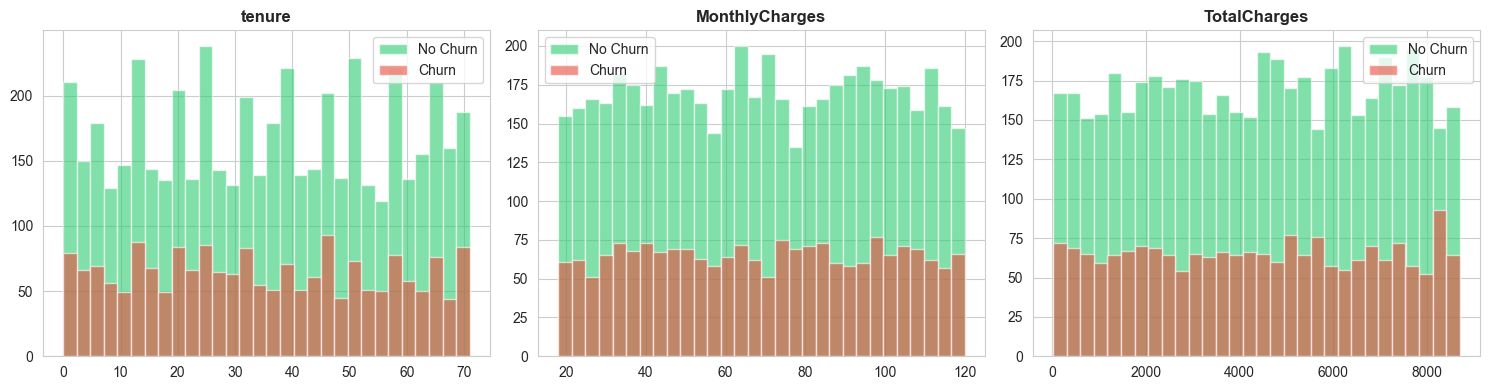

In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    df[df['Churn']=='No'][col].hist(ax=axes[i], alpha=0.6, label='No Churn', color='#2ecc71', bins=30)
    df[df['Churn']=='Yes'][col].hist(ax=axes[i], alpha=0.6, label='Churn', color='#e74c3c', bins=30)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()
plt.tight_layout()
plt.savefig('../data/processed/01_numerical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ Churn Rate by Category

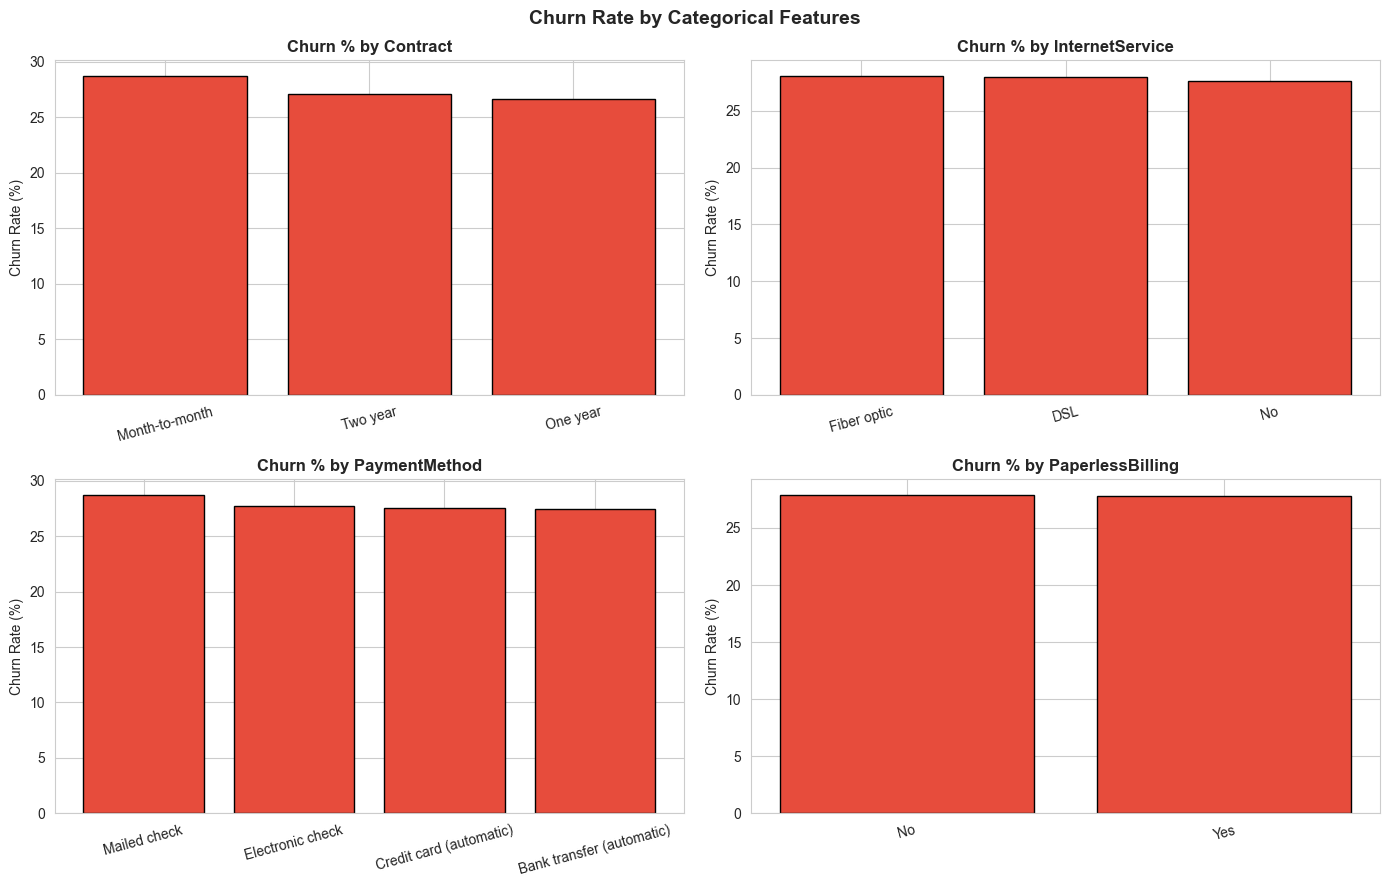

In [6]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100).reset_index()
    rate.columns = [col, 'Rate']
    rate = rate.sort_values('Rate', ascending=False)
    axes[i].bar(rate[col], rate['Rate'], color='#e74c3c', edgecolor='black')
    axes[i].set_title(f'Churn % by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/01_categorical_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ Key Insights

| Finding | Impact |
|---|---|
| ~26.5% churn rate | Class imbalance → need SMOTE |
| Low tenure → high churn | Recent customers most at risk |
| Month-to-month contract | Highest churn category |
| Fiber optic internet | Higher churn than DSL |

➡️ Next: `02_Data_Preprocessing.ipynb`